# Incidencia de dengue confirmado en México, 2020-2026

En el notebook anterior se realizó un análisis exploratorio de los casos confirmados de dengue en México durante el periodo 2020--2026. Ese análisis permitió describir la evolución temporal de los casos, su distribución por estado, región, municipio, sexo y grupo de edad. Sin embargo, los conteos absolutos no siempre permiten comparar adecuadamente la carga de la enfermedad entre entidades federativas, ya que cada estado tiene un tamaño poblacional distinto.

Por ejemplo, un estado con muchos habitantes puede presentar un número elevado de casos confirmados, pero una incidencia relativamente baja. En contraste, un estado con menor población puede tener menos casos absolutos, pero una carga mucho mayor en términos relativos. Por esta razón, en este notebook se incorpora información de población estatal anual para calcular tasas de incidencia.

La incidencia se define como el número de casos confirmados dividido entre la población correspondiente, multiplicado por 100,000 habitantes:

$$
\text{Incidencia} =
\frac{\text{Casos confirmados}}{\text{Población}}
\times 100{,}000.
$$

Este indicador permite comparar la intensidad del dengue entre estados, regiones y años de forma más adecuada que los conteos absolutos. En particular, se analizará la incidencia anual nacional, la incidencia estatal anual, la incidencia mensual nacional, los patrones estacionales, los estados con mayor incidencia durante 2024 y las diferencias regionales.

El año 2026 debe interpretarse con cautela, ya que la información disponible llega únicamente hasta mayo. Por ello, cuando se comparan promedios anuales entre estados, se privilegia el periodo 2020--2025, que contiene años completos.

Este análisis es importante porque permite identificar no sólo dónde hubo más casos, sino dónde la carga relativa del dengue fue mayor. Esto ayuda a distinguir entre estados con alta carga absoluta y estados con alta incidencia poblacional, lo cual es fundamental para interpretar la magnitud del problema epidemiológico y para orientar análisis posteriores de riesgo, estacionalidad, concentración espacial y modelado predictivo.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm

In [2]:
BASE = Path("datos_dengue_historicos")

DATA_DIR = BASE / "csv_unificado"

FIG_DIR = BASE / "figuras_incidencia"
TABLE_DIR = BASE / "tablas_incidencia"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Dataset de dengue
DENGUE_PATH = DATA_DIR / "dengue_2020_2026.csv"

# Dataset de población 
POB_PATH = Path("poblacion_estatal_2020_2026.csv")



df = pd.read_csv(
    DENGUE_PATH,
    parse_dates=["FECHA"]
)

df = df.set_index("FECHA").sort_index()


pop = pd.read_csv(POB_PATH)

pop["ANIO"] = pd.to_numeric(pop["ANIO"], errors="coerce").astype(int)
pop["POBLACION"] = pd.to_numeric(pop["POBLACION"], errors="coerce")

print("Dataset de dengue:")
print(df.shape)

print("\nRango temporal dengue:")
print(df.index.min(), "a", df.index.max())

print("\nCasos confirmados por año:")
display(df.groupby(df.index.year).size())

print("\nDataset de población:")
print(pop.shape)

print("\nAños disponibles en población:")
print(sorted(pop["ANIO"].unique()))

print("\nNúmero de estados en población:")
print(pop["ESTADO"].nunique())

print("\nValores faltantes en población:")
print(pop.isna().sum())


estados_dengue = set(df["ESTADO"].unique())
estados_pob = set(pop["ESTADO"].unique())

print("\nEstados en dengue que no están en población:")
print(sorted(estados_dengue - estados_pob))

print("\nEstados en población que no están en dengue:")
print(sorted(estados_pob - estados_dengue))

display(pop.head())

Dataset de dengue:
(242999, 8)

Rango temporal dengue:
2020-01-01 00:00:00 a 2026-05-20 00:00:00

Casos confirmados por año:


FECHA
2020     24224
2021      6326
2022     12122
2023     53319
2024    123140
2025     21732
2026      2136
dtype: int64


Dataset de población:
(224, 4)

Años disponibles en población:
[2020, 2021, 2022, 2023, 2024, 2025, 2026]

Número de estados en población:
32

Valores faltantes en población:
Unnamed: 0    0
ESTADO        0
ANIO          0
POBLACION     0
dtype: int64

Estados en dengue que no están en población:
[]

Estados en población que no están en dengue:
[]


,Unnamed: 0,ESTADO,ANIO,POBLACION
0,0,AGUASCALIENTES,2020,1456050
1,1,BAJA CALIFORNIA,2020,3838619
2,2,BAJA CALIFORNIA SUR,2020,815098
3,3,CAMPECHE,2020,939179
4,4,CHIAPAS,2020,5715260


In [3]:
# panel completo estado-año con ceros


# Casos confirmados por estado y año
casos_estado_anio = (
    df
    .assign(ANIO=df.index.year)
    .groupby(["ANIO", "ESTADO"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
)

# Usar población como panel base completo: 32 estados x 7 años
incidencia_estado_anio = pop.merge(
    casos_estado_anio,
    on=["ANIO", "ESTADO"],
    how="left"
)

# Los pares estado-año 
incidencia_estado_anio["CASOS_CONFIRMADOS"] = (
    incidencia_estado_anio["CASOS_CONFIRMADOS"]
    .fillna(0)
    .astype(int)
)

# Calcular incidencia por 100,000 habitantes
incidencia_estado_anio["INCIDENCIA_100K"] = (
    incidencia_estado_anio["CASOS_CONFIRMADOS"]
    / incidencia_estado_anio["POBLACION"]
    * 100_000
)


incidencia_estado_anio = incidencia_estado_anio.sort_values(
    ["ANIO", "ESTADO"]
).reset_index(drop=True)

# Revisión
print("Dimensiones esperadas: 224 filas")
print("Dimensiones obtenidas:")
print(incidencia_estado_anio.shape)

print("\nValores faltantes:")
print(incidencia_estado_anio.isna().sum())

print("\nCasos confirmados nacionales por año, desde tabla de incidencia:")
print(
    incidencia_estado_anio
    .groupby("ANIO")["CASOS_CONFIRMADOS"]
    .sum()
)

print("\nTop 20 estado-año por incidencia:")
display(
    incidencia_estado_anio
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(20)
)

# Guardar tabla
incidencia_estado_anio.to_csv(
    TABLE_DIR / "tabla_01_incidencia_estatal_anual.csv",
    index=False,
    encoding="utf-8"
)


Dimensiones esperadas: 224 filas
Dimensiones obtenidas:
(224, 6)

Valores faltantes:
Unnamed: 0           0
ESTADO               0
ANIO                 0
POBLACION            0
CASOS_CONFIRMADOS    0
INCIDENCIA_100K      0
dtype: int64

Casos confirmados nacionales por año, desde tabla de incidencia:
ANIO
2020     24224
2021      6326
2022     12122
2023     53319
2024    123140
2025     21732
2026      2136
Name: CASOS_CONFIRMADOS, dtype: int64

Top 20 estado-año por incidencia:


,Unnamed: 0,ESTADO,ANIO,POBLACION,CASOS_CONFIRMADOS,INCIDENCIA_100K
135,135,COLIMA,2024,762387,5043,661.475078
126,126,YUCATAN,2023,2452378,10385,423.466529
145,145,NAYARIT,2024,1309432,5490,419.265758
144,144,MORELOS,2024,2043884,6343,310.340509
130,130,BAJA CALIFORNIA SUR,2024,886050,2569,289.938491
118,118,QUINTANA ROO,2023,2019606,4967,245.939059
141,141,JALISCO,2024,8820915,20419,231.483922
128,128,AGUASCALIENTES,2024,1530185,3205,209.451798
112,112,MORELOS,2023,2030857,4172,205.430515
99,99,CAMPECHE,2023,950291,1906,200.570141


In [4]:
# Incidencia nacional anual por 100,000 habitantes


incidencia_nacional_anual = (
    incidencia_estado_anio
    .groupby("ANIO")
    .agg(
        CASOS_CONFIRMADOS=("CASOS_CONFIRMADOS", "sum"),
        POBLACION=("POBLACION", "sum")
    )
    .reset_index()
)

incidencia_nacional_anual["INCIDENCIA_100K"] = (
    incidencia_nacional_anual["CASOS_CONFIRMADOS"]
    / incidencia_nacional_anual["POBLACION"]
    * 100_000
)

print("Incidencia nacional anual por 100,000 habitantes:")
display(incidencia_nacional_anual)



Incidencia nacional anual por 100,000 habitantes:


,ANIO,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
0,2020,24224,128209170,18.894124
1,2021,6326,128982939,4.904525
2,2022,12122,129960600,9.327442
3,2023,53319,131135337,40.659521
4,2024,123140,132274416,93.094344
5,2025,21732,133367428,16.294833
6,2026,2136,134407258,1.589200


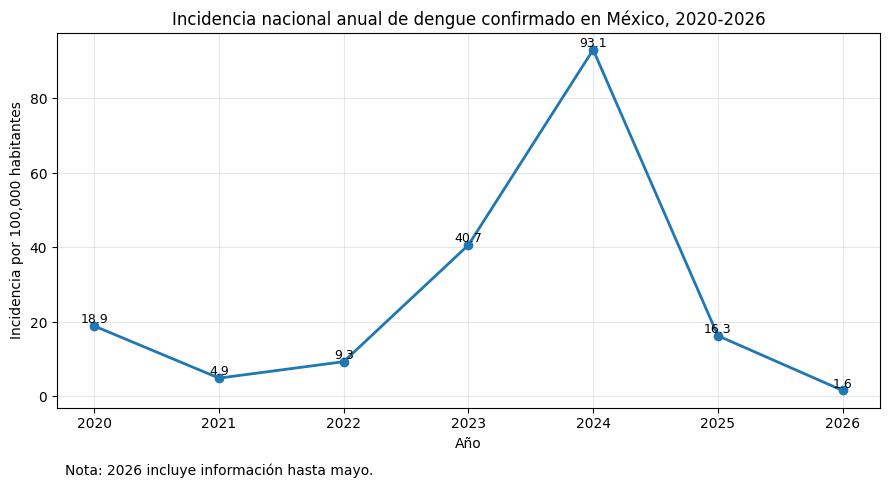

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    incidencia_nacional_anual["ANIO"],
    incidencia_nacional_anual["INCIDENCIA_100K"],
    marker="o",
    linewidth=2
)

ax.set_title("Incidencia nacional anual de dengue confirmado en México, 2020-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Incidencia por 100,000 habitantes")
ax.set_xticks(incidencia_nacional_anual["ANIO"])

ax.grid(True, alpha=0.3)

for _, row in incidencia_nacional_anual.iterrows():
    ax.text(
        row["ANIO"],
        row["INCIDENCIA_100K"],
        f"{row['INCIDENCIA_100K']:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.text(
    0.01,
    -0.18,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "incidencia_nacional_anual_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# Guardar tabla

incidencia_nacional_anual.to_csv(
    TABLE_DIR / "tabla_02_incidencia_nacional_anual.csv",
    index=False,
    encoding="utf-8"
)


- 2024 fue el máximo: 93.1 casos por 100,000 habitantes.
- 2023 fue el segundo año más alto: 40.7 por 100,000.
- 2026 no es comparable directamente porque sólo llega hasta mayo.

In [6]:
# Mapa de calor de incidencia estatal anual

# Tabla pivote: estados x años
incidencia_pivot = incidencia_estado_anio.pivot(
    index="ESTADO",
    columns="ANIO",
    values="INCIDENCIA_100K"
)

# Ordenar estados según la incidencia de 2024, porque fue el año de mayor carga nacional.
orden_estados = (
    incidencia_pivot[2024]
    .sort_values(ascending=False)
    .index
)

incidencia_pivot = incidencia_pivot.loc[orden_estados]

print("Incidencia estatal anual por 100,000 habitantes:")
incidencia_pivot.round(1)

Incidencia estatal anual por 100,000 habitantes:


ANIO,2020,2021,2022,2023,2024,2025,2026
ESTADO,,,,,,,
COLIMA,49.9,19.5,19.8,79.5,661.5,6.0,0.0
NAYARIT,65.3,3.6,0.7,19.4,419.3,38.1,4.8
MORELOS,30.9,28.3,29.1,205.4,310.3,6.6,0.1
BAJA CALIFORNIA SUR,3.7,1.0,10.5,82.9,289.9,73.3,14.9
JALISCO,63.0,2.1,0.8,11.0,231.5,25.9,0.5
AGUASCALIENTES,0.3,0.0,0.0,28.4,209.5,3.9,0.0
GUERRERO,16.3,8.8,23.6,99.8,182.7,13.3,0.4
NUEVO LEON,38.7,1.3,1.0,1.6,167.1,1.7,0.1
COAHUILA,30.4,33.1,17.2,4.6,166.2,21.1,0.1


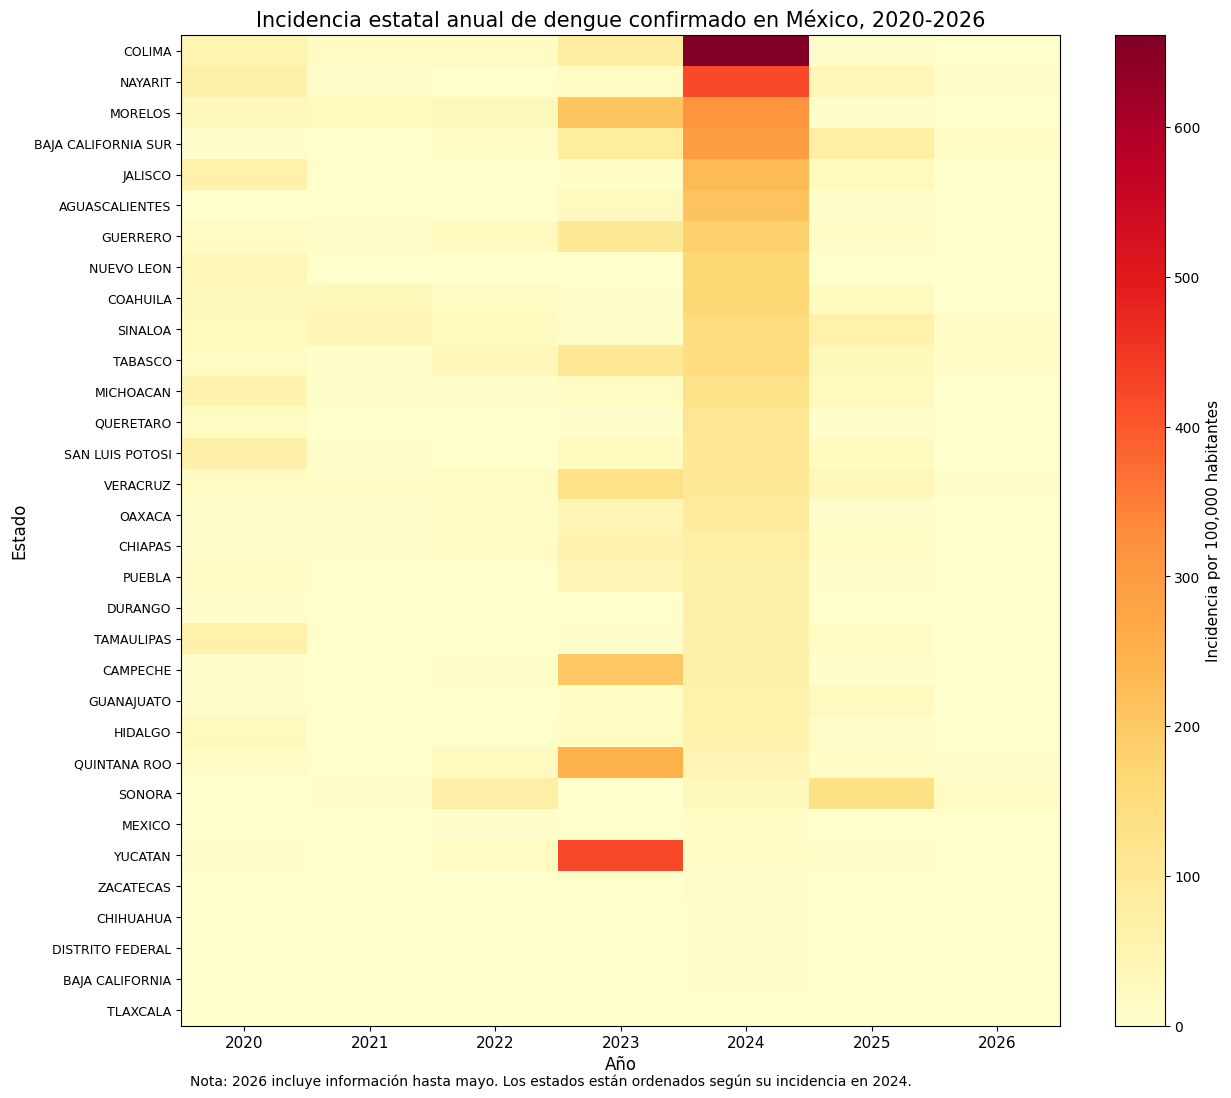

In [7]:
fig, ax = plt.subplots(figsize=(13, 11))

im = ax.imshow(
    incidencia_pivot.values,
    aspect="auto", cmap='YlOrRd'
)

ax.set_title(
    "Incidencia estatal anual de dengue confirmado en México, 2020-2026",
    fontsize=15
)

ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Estado", fontsize=12)

ax.set_xticks(range(len(incidencia_pivot.columns)))
ax.set_xticklabels(incidencia_pivot.columns, fontsize=11)

ax.set_yticks(range(len(incidencia_pivot.index)))
ax.set_yticklabels(incidencia_pivot.index, fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Incidencia por 100,000 habitantes", fontsize=11)

ax.text(
    0.01,
    -0.06,
    "Nota: 2026 incluye información hasta mayo. Los estados están ordenados según su incidencia en 2024.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "heatmap_incidencia_estatal_anual_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla pivote
incidencia_pivot.to_csv(
    TABLE_DIR / "tabla_03_heatmap_incidencia_estatal_anual.csv",
    encoding="utf-8"
)


In [8]:
# Top 15 estados por incidencia en 2024

top15_incidencia_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(15)
    .copy()
)

print("Top 15 estados por incidencia en 2024:")
display(
    top15_incidencia_2024[
        [
            "ESTADO",
            "ANIO",
            "CASOS_CONFIRMADOS",
            "POBLACION",
            "INCIDENCIA_100K"
        ]
    ].round({"INCIDENCIA_100K": 1})
)

Top 15 estados por incidencia en 2024:


,ESTADO,ANIO,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
135,COLIMA,2024,5043,762387,661.5
145,NAYARIT,2024,5490,1309432,419.3
144,MORELOS,2024,6343,2043884,310.3
130,BAJA CALIFORNIA SUR,2024,2569,886050,289.9
141,JALISCO,2024,20419,8820915,231.5
128,AGUASCALIENTES,2024,3205,1530185,209.5
139,GUERRERO,2024,6589,3606733,182.7
146,NUEVO LEON,2024,10544,6308199,167.1
134,COAHUILA,2024,5584,3358991,166.2
152,SINALOA,2024,4672,3165686,147.6


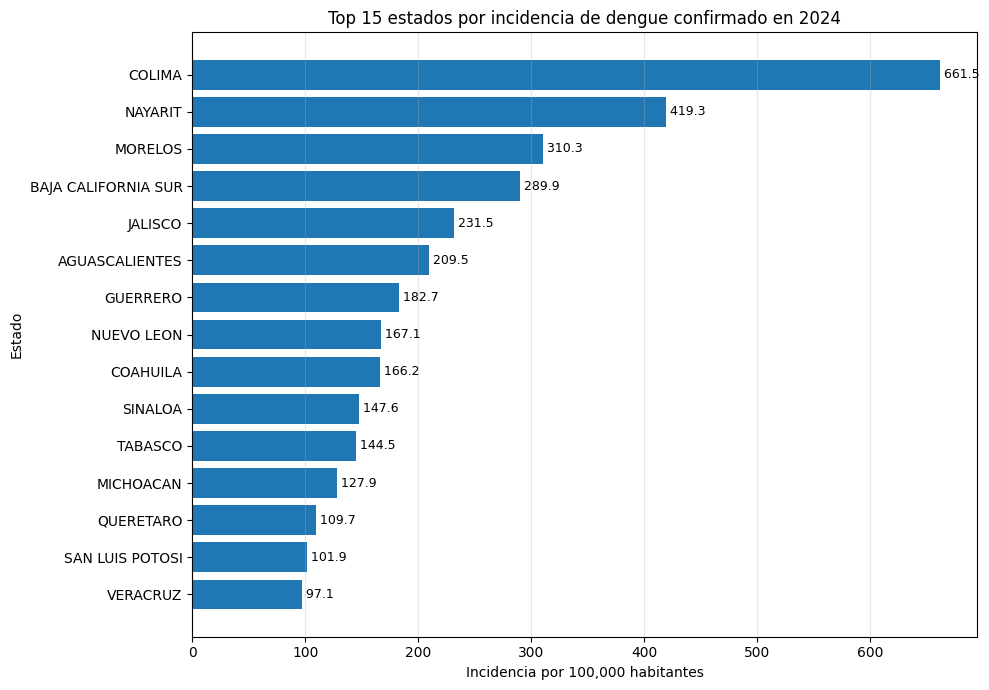

In [9]:
plot_data = top15_incidencia_2024.sort_values(
    "INCIDENCIA_100K",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_data["ESTADO"],
    plot_data["INCIDENCIA_100K"]
)

ax.set_title("Top 15 estados por incidencia de dengue confirmado en 2024")
ax.set_xlabel("Incidencia por 100,000 habitantes")
ax.set_ylabel("Estado")

for i, value in enumerate(plot_data["INCIDENCIA_100K"]):
    ax.text(
        value,
        i,
        f" {value:.1f}",
        va="center",
        fontsize=9
    )

ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_03_top15_estados_incidencia_dengue_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# Guardar tabla
top15_incidencia_2024.to_csv(
    TABLE_DIR / "tabla_04_top15_estados_incidencia_2024.csv",
    index=False,
    encoding="utf-8"
)


In [10]:
# Incidencia nacional mensual por 100,000 habitantes

# Casos confirmados por mes
casos_mensuales = (
    df
    .assign(
        ANIO=df.index.year,
        MES=df.index.month,
        FECHA_MES=df.index.to_period("M").to_timestamp()
    )
    .groupby(["FECHA_MES", "ANIO", "MES"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
)


# Población nacional por año
pob_nacional_anual = (
    pop
    .groupby("ANIO", as_index=False)["POBLACION"]
    .sum()
)


# Unir y calcular incidencia mensual
incidencia_nacional_mensual = casos_mensuales.merge(
    pob_nacional_anual,
    on="ANIO",
    how="left"
)

incidencia_nacional_mensual["INCIDENCIA_100K"] = (
    incidencia_nacional_mensual["CASOS_CONFIRMADOS"]
    / incidencia_nacional_mensual["POBLACION"]
    * 100_000
)

incidencia_nacional_mensual = incidencia_nacional_mensual.sort_values(
    "FECHA_MES"
).reset_index(drop=True)

print("Incidencia nacional mensual:")
display(incidencia_nacional_mensual.head(15))

print("\nÚltimos meses:")
display(incidencia_nacional_mensual.tail(15))

print("\nMeses con mayor incidencia:")
display(
    incidencia_nacional_mensual
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(15)
)



Incidencia nacional mensual:


,FECHA_MES,ANIO,MES,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
0,2020-01-01,2020,1,1140,128209170,0.889172
1,2020-02-01,2020,2,864,128209170,0.673899
2,2020-03-01,2020,3,567,128209170,0.442246
3,2020-04-01,2020,4,477,128209170,0.372048
4,2020-05-01,2020,5,914,128209170,0.712898
5,2020-06-01,2020,6,1531,128209170,1.194142
6,2020-07-01,2020,7,1808,128209170,1.410196
7,2020-08-01,2020,8,3060,128209170,2.386725
8,2020-09-01,2020,9,4621,128209170,3.604266
9,2020-10-01,2020,10,5993,128209170,4.674393



Últimos meses:


,FECHA_MES,ANIO,MES,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
62,2025-03-01,2025,3,639,133367428,0.479127
63,2025-04-01,2025,4,520,133367428,0.389900
64,2025-05-01,2025,5,751,133367428,0.563106
65,2025-06-01,2025,6,935,133367428,0.701071
66,2025-07-01,2025,7,1374,133367428,1.030237
67,2025-08-01,2025,8,2729,133367428,2.046227
68,2025-09-01,2025,9,3261,133367428,2.445125
69,2025-10-01,2025,10,4648,133367428,3.485109
70,2025-11-01,2025,11,3883,133367428,2.911505
71,2025-12-01,2025,12,798,133367428,0.598347



Meses con mayor incidencia:


,FECHA_MES,ANIO,MES,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
56,2024-09-01,2024,9,25771,132274416,19.482982
57,2024-10-01,2024,10,24452,132274416,18.485812
55,2024-08-01,2024,8,21599,132274416,16.328932
58,2024-11-01,2024,11,16505,132274416,12.477848
44,2023-09-01,2023,9,14145,131135337,10.786566
45,2023-10-01,2023,10,12187,131135337,9.293452
54,2024-07-01,2024,7,10663,132274416,8.061272
43,2023-08-01,2023,8,8805,131135337,6.714437
46,2023-11-01,2023,11,6955,131135337,5.303681
53,2024-06-01,2024,6,6969,132274416,5.268593


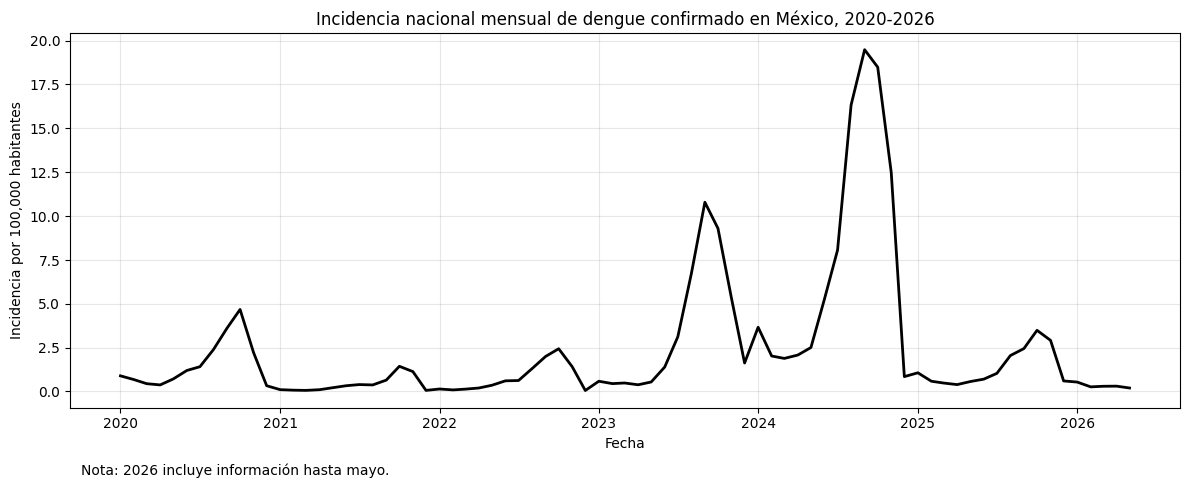

In [11]:
# incidencia nacional mensual

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    incidencia_nacional_mensual["FECHA_MES"],
    incidencia_nacional_mensual["INCIDENCIA_100K"],
    linewidth=2, color = 'black'
)

ax.set_title("Incidencia nacional mensual de dengue confirmado en México, 2020-2026")
ax.set_xlabel("Fecha")
ax.set_ylabel("Incidencia por 100,000 habitantes")
ax.grid(True, alpha=0.3)

ax.text(
    0.01,
    -0.18,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_04_incidencia_nacional_mensual_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla
incidencia_nacional_mensual.to_csv(
    TABLE_DIR / "tabla_05_incidencia_nacional_mensual.csv",
    index=False,
    encoding="utf-8"
)


In [12]:
# Estacionalidad mensual de la incidencia nacional

# Tabla mes x año
estacionalidad_incidencia = incidencia_nacional_mensual.pivot(
    index="MES",
    columns="ANIO",
    values="INCIDENCIA_100K"
)

# Asegurar orden de meses
estacionalidad_incidencia = estacionalidad_incidencia.reindex(range(1, 13))

meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

estacionalidad_incidencia.index = estacionalidad_incidencia.index.map(meses)

print("Estacionalidad mensual de la incidencia nacional:")
estacionalidad_incidencia.round(2)

Estacionalidad mensual de la incidencia nacional:


ANIO,2020,2021,2022,2023,2024,2025,2026
MES,,,,,,,
Ene,0.89,0.10,0.14,0.58,3.66,1.06,0.53
Feb,0.67,0.07,0.09,0.45,2.02,0.58,0.26
Mar,0.44,0.06,0.13,0.48,1.88,0.48,0.29
Abr,0.37,0.10,0.20,0.38,2.08,0.39,0.30
May,0.71,0.21,0.35,0.54,2.50,0.56,0.20
Jun,1.19,0.33,0.60,1.39,5.27,0.70,NaN
Jul,1.41,0.39,0.62,3.12,8.06,1.03,NaN
Ago,2.39,0.37,1.30,6.71,16.33,2.05,NaN
Sep,3.60,0.65,1.99,10.79,19.48,2.45,NaN


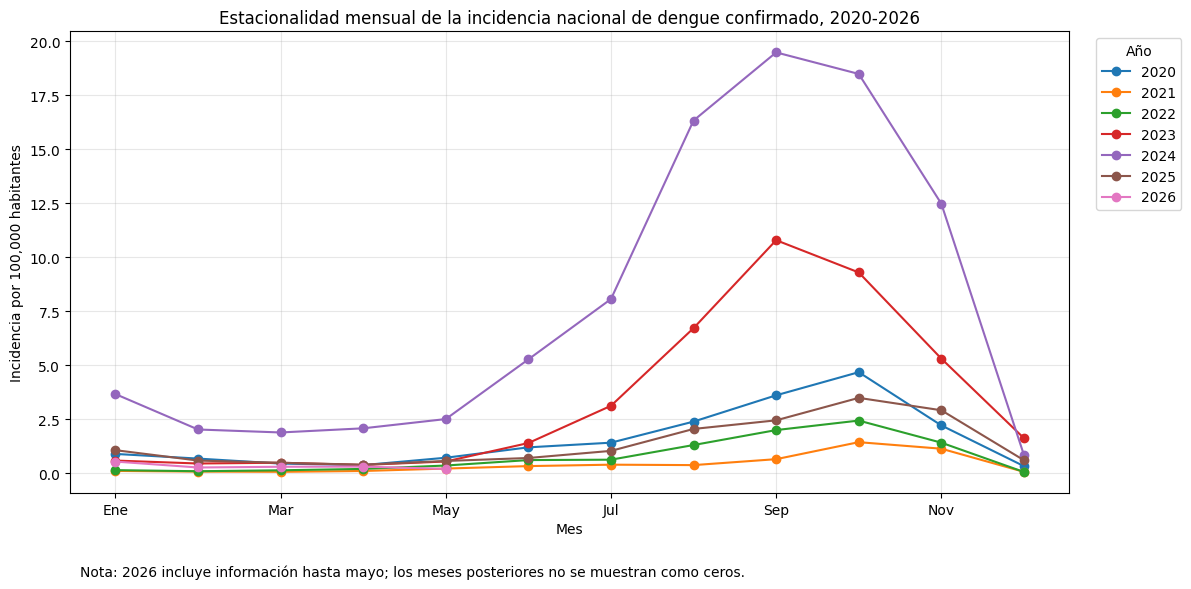

In [13]:
# estacionalidad mensual
fig, ax = plt.subplots(figsize=(12, 6))

estacionalidad_incidencia.plot(
    marker="o",
    ax=ax
)

ax.set_title("Estacionalidad mensual de la incidencia nacional de dengue confirmado, 2020-2026")
ax.set_xlabel("Mes")
ax.set_ylabel("Incidencia por 100,000 habitantes")

ax.grid(True, alpha=0.3)
ax.legend(title="Año", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.text(
    0.01,
    -0.18,
    "Nota: 2026 incluye información hasta mayo; los meses posteriores no se muestran como ceros.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_05_estacionalidad_mensual_incidencia_nacional_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla
estacionalidad_incidencia.to_csv(
    TABLE_DIR / "tabla_06_estacionalidad_mensual_incidencia_nacional.csv",
    encoding="utf-8"
)

In [14]:
# Incidencia mensual en 2024 para los estados con mayor incidencia anual en 2024

# Top 10 estados por incidencia anual en 2024
top10_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(10)
    .copy()
)

top10_estados_2024 = top10_2024["ESTADO"].tolist()

print("Top 10 estados por incidencia en 2024:")
display(
    top10_2024[
        ["ESTADO", "CASOS_CONFIRMADOS", "POBLACION", "INCIDENCIA_100K"]
    ].round({"INCIDENCIA_100K": 2})
)


# Casos mensuales por estado en 2024
df_tmp = df.copy()
df_tmp["ANIO"] = df_tmp.index.year
df_tmp["MES"] = df_tmp.index.month

casos_estado_mes_2024 = (
    df_tmp[df_tmp["ANIO"] == 2024]
    .groupby(["ESTADO", "MES"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
)

# Crear malla completa estado-mes para no perder meses con 0 casos
malla_2024 = pd.MultiIndex.from_product(
    [top10_estados_2024, range(1, 13)],
    names=["ESTADO", "MES"]
).to_frame(index=False)

casos_estado_mes_2024 = (
    malla_2024
    .merge(casos_estado_mes_2024, on=["ESTADO", "MES"], how="left")
)

casos_estado_mes_2024["CASOS_CONFIRMADOS"] = (
    casos_estado_mes_2024["CASOS_CONFIRMADOS"]
    .fillna(0)
    .astype(int)
)


# Población 2024 por estado
pob_2024 = (
    pop
    .query("ANIO == 2024")
    [["ESTADO", "POBLACION"]]
    .drop_duplicates()
)

incidencia_estado_mes_2024 = casos_estado_mes_2024.merge(
    pob_2024,
    on="ESTADO",
    how="left"
)

incidencia_estado_mes_2024["INCIDENCIA_100K"] = (
    incidencia_estado_mes_2024["CASOS_CONFIRMADOS"]
    / incidencia_estado_mes_2024["POBLACION"]
    * 100_000
)

# Orden de estados según incidencia anual 2024
orden_estados = top10_2024["ESTADO"].tolist()


# Tabla pivote


tabla_estado_mes_2024 = (
    incidencia_estado_mes_2024
    .pivot(index="MES", columns="ESTADO", values="INCIDENCIA_100K")
)

tabla_estado_mes_2024 = tabla_estado_mes_2024[orden_estados]

meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

tabla_estado_mes_2024.index = tabla_estado_mes_2024.index.map(meses)

print("\nIncidencia mensual por 100,000 habitantes en 2024, top 10 estados:")
tabla_estado_mes_2024.round(2)


Top 10 estados por incidencia en 2024:


,ESTADO,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
135,COLIMA,5043,762387,661.48
145,NAYARIT,5490,1309432,419.27
144,MORELOS,6343,2043884,310.34
130,BAJA CALIFORNIA SUR,2569,886050,289.94
141,JALISCO,20419,8820915,231.48
128,AGUASCALIENTES,3205,1530185,209.45
139,GUERRERO,6589,3606733,182.69
146,NUEVO LEON,10544,6308199,167.15
134,COAHUILA,5584,3358991,166.24
152,SINALOA,4672,3165686,147.58



Incidencia mensual por 100,000 habitantes en 2024, top 10 estados:


ESTADO,COLIMA,NAYARIT,MORELOS,BAJA CALIFORNIA SUR,JALISCO,AGUASCALIENTES,GUERRERO,NUEVO LEON,COAHUILA,SINALOA
MES,,,,,,,,,,
Ene,28.86,4.96,5.38,14.45,0.71,0.33,53.40,0.05,0.00,2.21
Feb,24.27,5.04,3.23,7.67,0.48,0.07,13.64,0.00,0.00,1.96
Mar,20.99,7.94,3.87,4.29,0.41,0.00,7.87,0.02,0.00,0.95
Abr,25.97,13.82,6.95,1.69,0.83,0.00,8.01,0.00,0.00,1.30
May,30.56,19.32,13.06,2.82,1.54,0.07,9.93,0.16,0.03,1.33
Jun,34.37,33.22,35.91,9.71,6.89,0.52,13.28,1.51,1.40,2.84
Jul,66.11,48.34,68.84,18.28,14.06,1.11,14.36,9.13,6.58,2.91
Ago,144.55,100.43,86.40,38.37,34.19,12.42,13.61,40.77,26.88,9.51
Sep,131.56,101.42,49.66,75.96,53.03,47.12,21.46,38.01,29.65,34.15


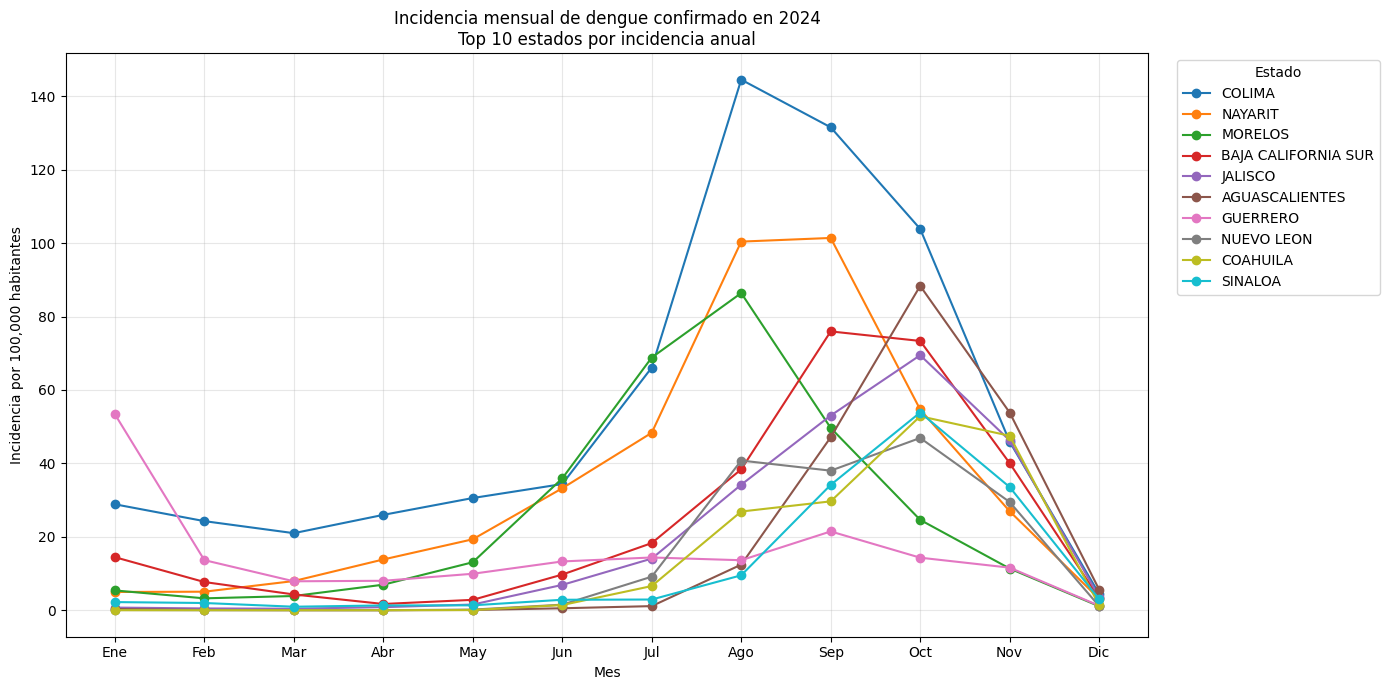

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

for estado in orden_estados:
    ax.plot(
        tabla_estado_mes_2024.index,
        tabla_estado_mes_2024[estado],
        marker="o",
        label=estado
    )

ax.set_title(
    "Incidencia mensual de dengue confirmado en 2024\n"
    "Top 10 estados por incidencia anual"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Incidencia por 100,000 habitantes")
ax.grid(True, alpha=0.3)
ax.legend(title="Estado", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()

fig_path = FIG_DIR / "fig_06_incidencia_mensual_top10_estados_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla
tabla_estado_mes_2024.to_csv(
    TABLE_DIR / "tabla_07_incidencia_mensual_top10_estados_2024.csv",
    encoding="utf-8"
)


- Colima tiene el pico más alto en agosto-septiembre.
- Nayarit también alcanza su máximo en agosto-septiembre.
- Morelos concentra su pico en julio-agosto.
- Baja California Sur se desplaza más hacia septiembre-octubre.
- Aguascalientes, Jalisco, Coahuila, Sinaloa y Nuevo León tienen mayor intensidad hacia septiembre-noviembre.
- Guerrero aparece con incidencia alta en enero, lo cual conviene revisar después porque podría indicar arrastre del brote de finales de 2023.

In [16]:
# Mapa de calor mensual de incidencia en 2024
# Top 10 estados por incidencia anual

tabla_heatmap_top10_2024 = tabla_estado_mes_2024.T.copy()

print("Mapa de calor mensual de incidencia en 2024, top 10 estados:")
tabla_heatmap_top10_2024.round(2)

Mapa de calor mensual de incidencia en 2024, top 10 estados:


MES,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
ESTADO,,,,,,,,,,,,
COLIMA,28.86,24.27,20.99,25.97,30.56,34.37,66.11,144.55,131.56,103.88,45.91,4.46
NAYARIT,4.96,5.04,7.94,13.82,19.32,33.22,48.34,100.43,101.42,54.68,26.96,3.13
MORELOS,5.38,3.23,3.87,6.95,13.06,35.91,68.84,86.40,49.66,24.61,11.35,1.08
BAJA CALIFORNIA SUR,14.45,7.67,4.29,1.69,2.82,9.71,18.28,38.37,75.96,73.36,40.07,3.27
JALISCO,0.71,0.48,0.41,0.83,1.54,6.89,14.06,34.19,53.03,69.47,46.27,3.61
AGUASCALIENTES,0.33,0.07,0.00,0.00,0.07,0.52,1.11,12.42,47.12,88.36,53.85,5.62
GUERRERO,53.40,13.64,7.87,8.01,9.93,13.28,14.36,13.61,21.46,14.31,11.59,1.22
NUEVO LEON,0.05,0.00,0.02,0.00,0.16,1.51,9.13,40.77,38.01,46.92,29.47,1.11
COAHUILA,0.00,0.00,0.00,0.00,0.03,1.40,6.58,26.88,29.65,52.84,47.51,1.34


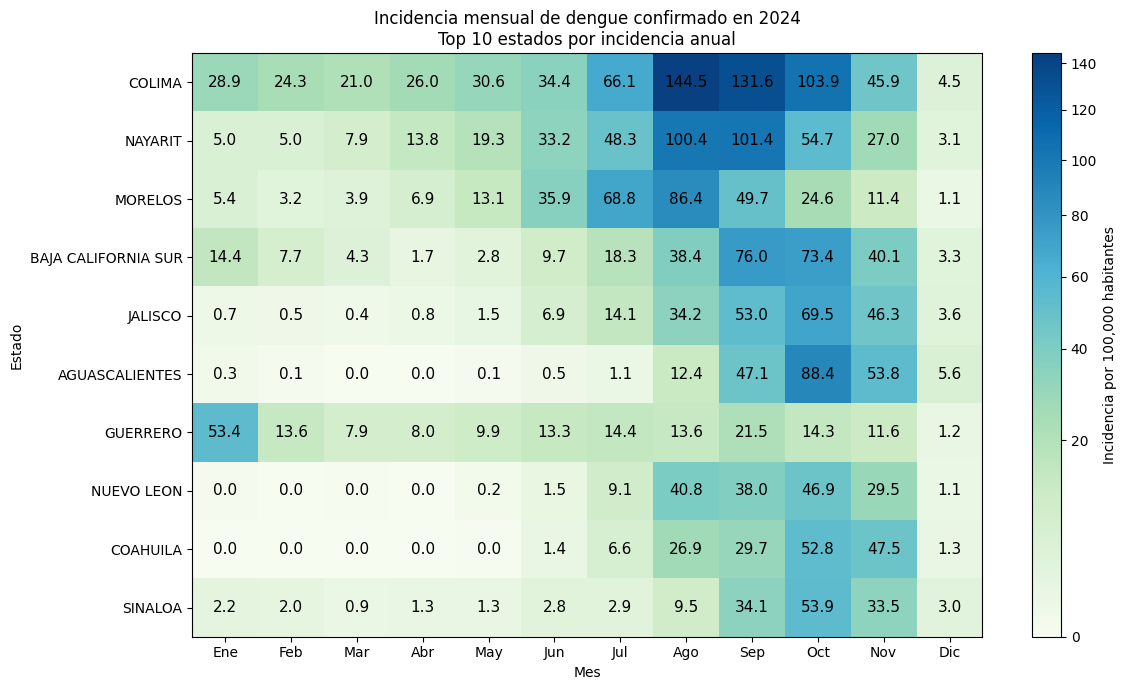

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(
    tabla_heatmap_top10_2024.values,
    aspect="auto",
    norm=PowerNorm(gamma=0.55), cmap= 'GnBu'
)

ax.set_title(
    "Incidencia mensual de dengue confirmado en 2024\n"
    "Top 10 estados por incidencia anual"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Estado")

ax.set_xticks(range(len(tabla_heatmap_top10_2024.columns)))
ax.set_xticklabels(tabla_heatmap_top10_2024.columns)

ax.set_yticks(range(len(tabla_heatmap_top10_2024.index)))
ax.set_yticklabels(tabla_heatmap_top10_2024.index)

# Etiquetas dentro de las celdas
for i in range(tabla_heatmap_top10_2024.shape[0]):
    for j in range(tabla_heatmap_top10_2024.shape[1]):
        valor = tabla_heatmap_top10_2024.iloc[i, j]
        ax.text(
            j,
            i,
            f"{valor:.1f}",
            ha="center",
            va="center",
            fontsize=11
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Incidencia por 100,000 habitantes")

fig.tight_layout()

fig_path = FIG_DIR / "fig_07_heatmap_incidencia_mensual_top10_estados_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()



tabla_heatmap_top10_2024.to_csv(
    TABLE_DIR / "tabla_08_heatmap_incidencia_mensual_top10_estados_2024.csv",
    encoding="utf-8"
)


In [18]:
# Mes pico de incidencia estatal en 2024

# Casos mensuales por estado en 2024, para los 32 estados
df_tmp = df.copy()
df_tmp["ANIO"] = df_tmp.index.year
df_tmp["MES"] = df_tmp.index.month

casos_estado_mes_2024_all = (
    df_tmp[df_tmp["ANIO"] == 2024]
    .groupby(["ESTADO", "MES"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
)

# Malla completa: 32 estados x 12 meses
estados = sorted(pop["ESTADO"].unique())

malla_estado_mes_2024 = pd.MultiIndex.from_product(
    [estados, range(1, 13)],
    names=["ESTADO", "MES"]
).to_frame(index=False)

casos_estado_mes_2024_all = (
    malla_estado_mes_2024
    .merge(casos_estado_mes_2024_all, on=["ESTADO", "MES"], how="left")
)

casos_estado_mes_2024_all["CASOS_CONFIRMADOS"] = (
    casos_estado_mes_2024_all["CASOS_CONFIRMADOS"]
    .fillna(0)
    .astype(int)
)


# Agregar población 2024 y calcular incidencia mensual


pob_2024 = (
    pop
    .query("ANIO == 2024")
    [["ESTADO", "POBLACION"]]
    .drop_duplicates()
)

incidencia_estado_mes_2024_all = casos_estado_mes_2024_all.merge(
    pob_2024,
    on="ESTADO",
    how="left"
)

incidencia_estado_mes_2024_all["INCIDENCIA_100K"] = (
    incidencia_estado_mes_2024_all["CASOS_CONFIRMADOS"]
    / incidencia_estado_mes_2024_all["POBLACION"]
    * 100_000
)


# Identificar mes pico por estado


idx_pico = (
    incidencia_estado_mes_2024_all
    .groupby("ESTADO")["INCIDENCIA_100K"]
    .idxmax()
)

pico_estado_2024 = (
    incidencia_estado_mes_2024_all
    .loc[idx_pico]
    .copy()
)

meses_nombre = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

pico_estado_2024["MES_PICO"] = pico_estado_2024["MES"].map(meses_nombre)

# Agregar incidencia anual 2024
incidencia_anual_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    [["ESTADO", "CASOS_CONFIRMADOS", "INCIDENCIA_100K"]]
    .rename(columns={
        "CASOS_CONFIRMADOS": "CASOS_ANUALES_2024",
        "INCIDENCIA_100K": "INCIDENCIA_ANUAL_100K"
    })
)

pico_estado_2024 = pico_estado_2024.merge(
    incidencia_anual_2024,
    on="ESTADO",
    how="left"
)

pico_estado_2024 = pico_estado_2024[
    [
        "ESTADO",
        "MES",
        "MES_PICO",
        "CASOS_CONFIRMADOS",
        "INCIDENCIA_100K",
        "CASOS_ANUALES_2024",
        "INCIDENCIA_ANUAL_100K",
        "POBLACION"
    ]
].rename(columns={
    "CASOS_CONFIRMADOS": "CASOS_MES_PICO",
    "INCIDENCIA_100K": "INCIDENCIA_MES_PICO_100K"
})

pico_estado_2024 = pico_estado_2024.sort_values(
    "INCIDENCIA_MES_PICO_100K",
    ascending=False
).reset_index(drop=True)

print("Mes pico de incidencia estatal en 2024:")
display(
    pico_estado_2024.round({
        "INCIDENCIA_MES_PICO_100K": 2,
        "INCIDENCIA_ANUAL_100K": 2
    })
)



Mes pico de incidencia estatal en 2024:


,ESTADO,MES,MES_PICO,CASOS_MES_PICO,INCIDENCIA_MES_PICO_100K,CASOS_ANUALES_2024,INCIDENCIA_ANUAL_100K,POBLACION
0,COLIMA,8,Ago,1102,144.55,5043,661.48,762387
1,NAYARIT,9,Sep,1328,101.42,5490,419.27,1309432
2,AGUASCALIENTES,10,Oct,1352,88.36,3205,209.45,1530185
3,MORELOS,8,Ago,1766,86.40,6343,310.34,2043884
4,BAJA CALIFORNIA SUR,9,Sep,673,75.96,2569,289.94,886050
5,JALISCO,10,Oct,6128,69.47,20419,231.48,8820915
6,SINALOA,10,Oct,1705,53.86,4672,147.58,3165686
7,GUERRERO,1,Ene,1926,53.40,6589,182.69,3606733
8,COAHUILA,10,Oct,1775,52.84,5584,166.24,3358991
9,NUEVO LEON,10,Oct,2960,46.92,10544,167.15,6308199


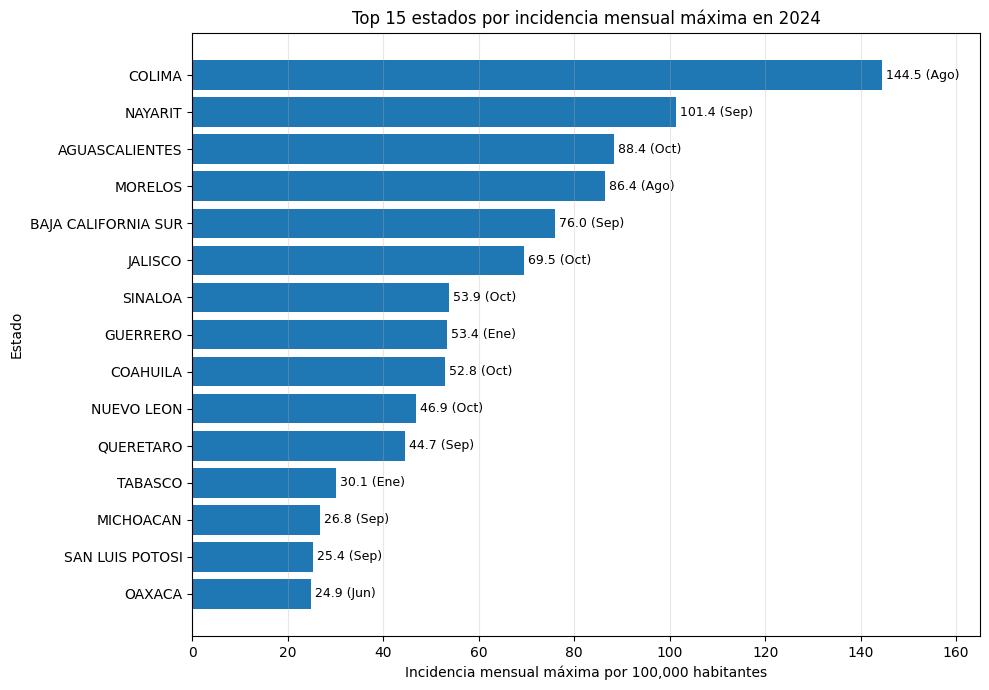

In [19]:
#  top 15 por incidencia en el mes pico
top15_pico_2024 = pico_estado_2024.head(15).copy()
plot_data = top15_pico_2024.sort_values(
    "INCIDENCIA_MES_PICO_100K",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_data["ESTADO"],
    plot_data["INCIDENCIA_MES_PICO_100K"]
)

ax.set_title("Top 15 estados por incidencia mensual máxima en 2024")
ax.set_xlabel("Incidencia mensual máxima por 100,000 habitantes")
ax.set_ylabel("Estado")
ax.set_xlim(0, 165)

for i, row in enumerate(plot_data.itertuples()):
    ax.text(
        row.INCIDENCIA_MES_PICO_100K,
        i,
        f" {row.INCIDENCIA_MES_PICO_100K:.1f} ({row.MES_PICO})",
        va="center",
        fontsize=9
    )

ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_08_top15_incidencia_mensual_maxima_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# Guardar tabla
pico_estado_2024.to_csv(
    TABLE_DIR / "tabla_09_mes_pico_incidencia_estatal_2024.csv",
    index=False,
    encoding="utf-8"
)

Picos principales:
- Agosto: Colima, Morelos, Chiapas, México, Distrito Federal.
- Septiembre: Nayarit, Baja California Sur, Querétaro, Michoacán, San Luis Potosí, Durango, Veracruz, Hidalgo, Puebla.
- Octubre: Aguascalientes, Jalisco, Sinaloa, Coahuila, Nuevo León, Guanajuato, Sonora, Chihuahua, Zacatecas, Baja California.
- Noviembre: Tamaulipas.

In [20]:
# Distribución de estados según mes pico en 2024

# Conteo de estados por mes pico
conteo_mes_pico_2024 = (
    pico_estado_2024
    .groupby(["MES", "MES_PICO"])
    .size()
    .reset_index(name="NUM_ESTADOS")
    .sort_values("MES")
)

print("Número de estados según mes pico de incidencia en 2024:")
conteo_mes_pico_2024

Número de estados según mes pico de incidencia en 2024:


,MES,MES_PICO,NUM_ESTADOS
0,1,Ene,5
1,6,Jun,1
2,7,Jul,1
3,8,Ago,5
4,9,Sep,9
5,10,Oct,10
6,11,Nov,1


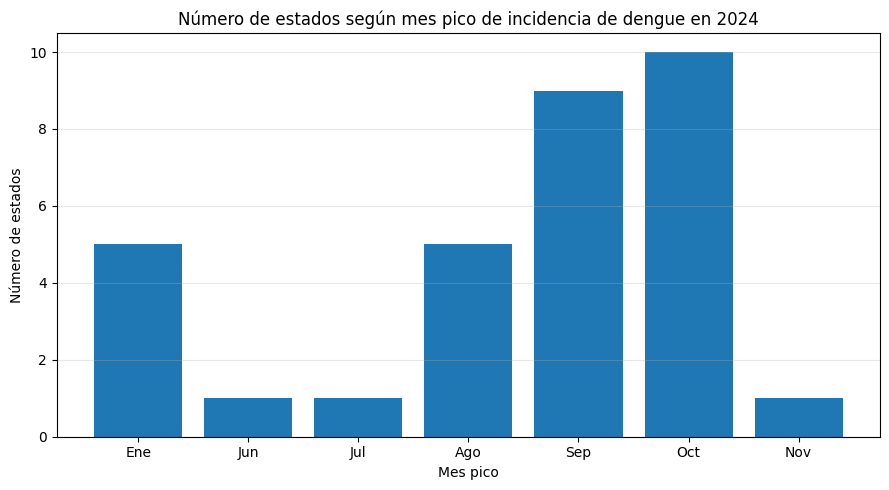

In [21]:
# número de estados por mes pico
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    conteo_mes_pico_2024["MES_PICO"],
    conteo_mes_pico_2024["NUM_ESTADOS"]
)

ax.set_title("Número de estados según mes pico de incidencia de dengue en 2024")
ax.set_xlabel("Mes pico")
ax.set_ylabel("Número de estados")



ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_09_numero_estados_mes_pico_incidencia_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# Guardar tabla
conteo_mes_pico_2024.to_csv(
    TABLE_DIR / "tabla_10_numero_estados_mes_pico_2024.csv",
    index=False,
    encoding="utf-8"
)


- 19 de los 32 estados (59.4%) alcanzaron su máximo entre septiembre y octubre (9 en septiembre y 10 en octubre), lo que confirma que el pico nacional ocurre al final del verano e inicio del otoño.
- Los estados con pico en enero (Guerrero, Tabasco, Campeche, Quintana Roo y Yucatán) probablemente reflejan la continuación del gran brote iniciado durante el segundo semestre de 2023.

In [22]:
#  Variabilidad de la incidencia estatal

resumen_estado = (
    incidencia_estado_anio
    .groupby("ESTADO")
    .agg(
        Incidencia_media=("INCIDENCIA_100K", "mean"),
        Incidencia_maxima=("INCIDENCIA_100K", "max"),
        Desv_std=("INCIDENCIA_100K", "std"),
        Anios_con_casos=("CASOS_CONFIRMADOS", lambda x: (x > 0).sum())
    )
    .fillna(0)
    .sort_values("Incidencia_media", ascending=False)
)

print("Resumen estatal de incidencia:")
resumen_estado.round(2)

Resumen estatal de incidencia:


,Incidencia_media,Incidencia_maxima,Desv_std,Anios_con_casos
ESTADO,,,,
COLIMA,119.46,661.48,240.58,6
MORELOS,87.25,310.34,121.02,7
NAYARIT,78.75,419.27,151.94,7
BAJA CALIFORNIA SUR,68.02,289.94,103.50,7
YUCATAN,67.08,423.47,157.28,7
TABASCO,50.43,144.50,52.88,7
QUINTANA ROO,49.64,245.94,87.97,7
GUERRERO,49.28,182.69,67.60,7
JALISCO,47.85,231.48,84.00,7


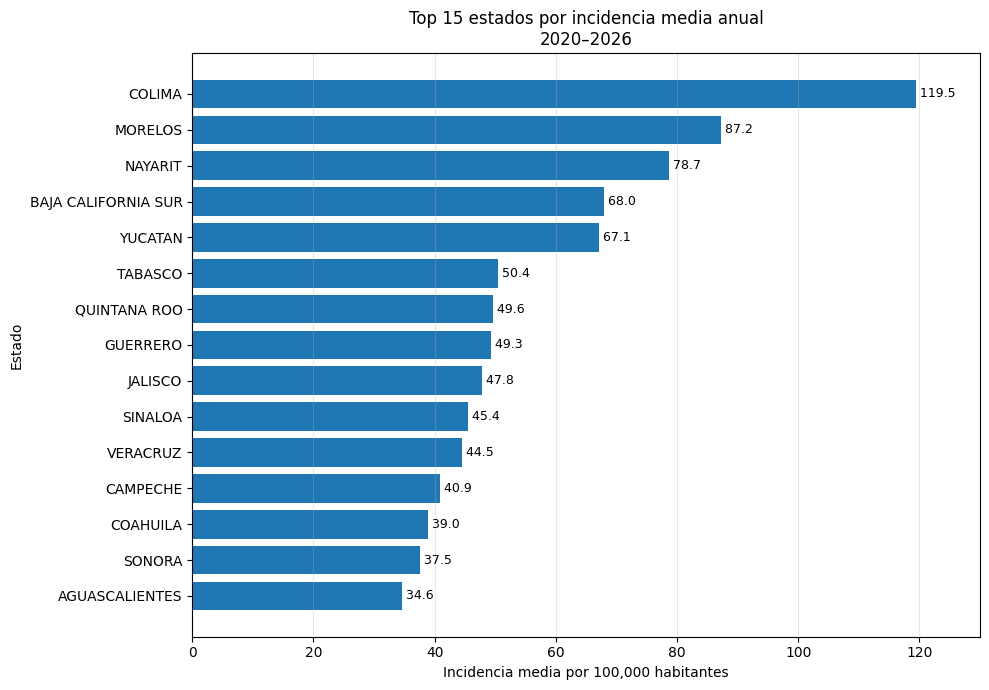

In [23]:
top15 = resumen_estado.head(15).sort_values(
    "Incidencia_media",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top15.index,
    top15["Incidencia_media"]
)

ax.set_title(
    "Top 15 estados por incidencia media anual\n"
    "2020–2026"
)

ax.set_xlabel("Incidencia media por 100,000 habitantes")
ax.set_ylabel("Estado")

for i, v in enumerate(top15["Incidencia_media"]):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=9)

ax.grid(True, axis="x", alpha=0.3)
ax.set_xlim(0,130)

fig.tight_layout()

fig_path = FIG_DIR / "fig_10_top15_incidencia_media_estatal_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# Guardar tabla
resumen_estado.to_csv(
    TABLE_DIR / "tabla_11_resumen_incidencia_estatal.csv",
    encoding="utf-8"
)


In [24]:
# Incidencia media estatal excluyendo 2026

resumen_estado_2020_2025 = (
    incidencia_estado_anio
    .query("ANIO <= 2025")
    .groupby("ESTADO")
    .agg(
        Incidencia_media=("INCIDENCIA_100K", "mean"),
        Incidencia_maxima=("INCIDENCIA_100K", "max"),
        Desv_std=("INCIDENCIA_100K", "std"),
        Anios_con_casos=("CASOS_CONFIRMADOS", lambda x: (x > 0).sum())
    )
    .fillna(0)
    .sort_values("Incidencia_media", ascending=False)
)

print("Resumen estatal de incidencia, 2020-2025:")
resumen_estado_2020_2025.round(2)

Resumen estatal de incidencia, 2020-2025:


,Incidencia_media,Incidencia_maxima,Desv_std,Anios_con_casos
ESTADO,,,,
COLIMA,139.37,661.48,257.15,6
MORELOS,101.77,310.34,125.71,6
NAYARIT,91.07,419.27,162.56,6
YUCATAN,78.20,423.47,169.26,6
BAJA CALIFORNIA SUR,76.88,289.94,110.43,6
GUERRERO,57.43,182.69,70.18,6
QUINTANA ROO,57.27,245.94,93.79,6
TABASCO,56.39,144.50,55.30,6
JALISCO,55.73,231.48,89.13,6


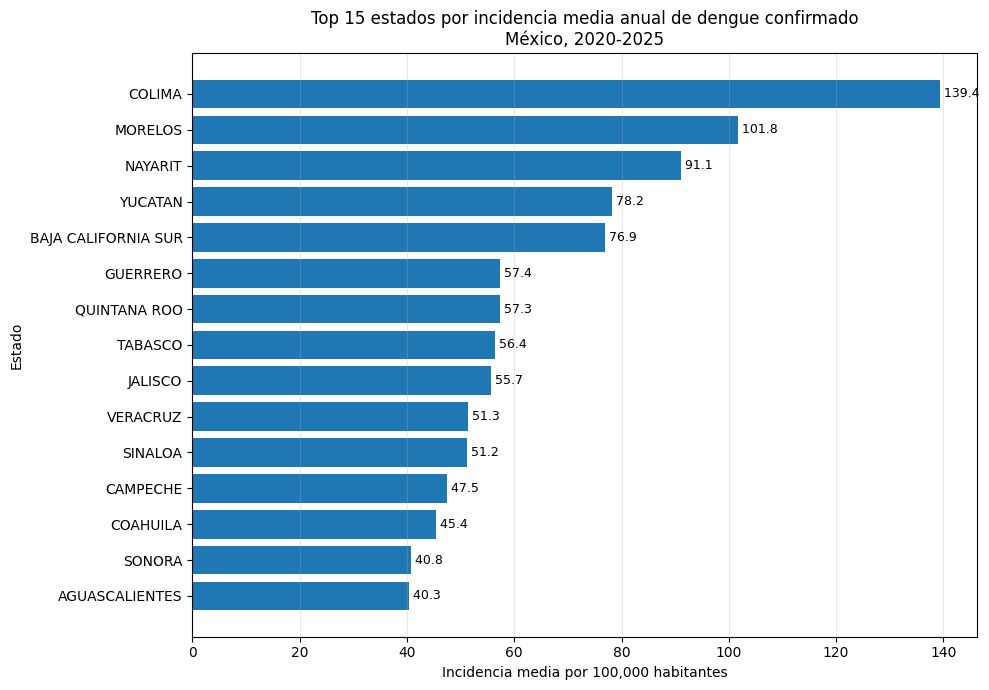

In [25]:
top15 = resumen_estado_2020_2025.head(15).sort_values(
    "Incidencia_media",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top15.index,
    top15["Incidencia_media"]
)

ax.set_title(
    "Top 15 estados por incidencia media anual de dengue confirmado\n"
    "México, 2020-2025"
)

ax.set_xlabel("Incidencia media por 100,000 habitantes")
ax.set_ylabel("Estado")

for i, v in enumerate(top15["Incidencia_media"]):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=9)

ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_11_top15_incidencia_media_estatal_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla
resumen_estado_2020_2025.to_csv(
    TABLE_DIR / "tabla_12_resumen_incidencia_estatal_2020_2025.csv",
    encoding="utf-8"
)


In [27]:
# Casos absolutos vs incidencia estatal en 2024

comparacion_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .copy()
    .sort_values("INCIDENCIA_100K", ascending=False)
)

print("Comparación estatal 2024: casos absolutos e incidencia:")
display(
    comparacion_2024[
        [
            "ESTADO",
            "CASOS_CONFIRMADOS",
            "POBLACION",
            "INCIDENCIA_100K"
        ]
    ].round({"INCIDENCIA_100K": 2})
)

# Estados a etiquetar: top 8 por incidencia y top 8 por casos absolutos

top_incidencia = set(
    comparacion_2024
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(8)["ESTADO"]
)

top_casos = set(
    comparacion_2024
    .sort_values("CASOS_CONFIRMADOS", ascending=False)
    .head(8)["ESTADO"]
)

estados_etiquetar = top_incidencia.union(top_casos)

Comparación estatal 2024: casos absolutos e incidencia:


,ESTADO,CASOS_CONFIRMADOS,POBLACION,INCIDENCIA_100K
135,COLIMA,5043,762387,661.48
145,NAYARIT,5490,1309432,419.27
144,MORELOS,6343,2043884,310.34
130,BAJA CALIFORNIA SUR,2569,886050,289.94
141,JALISCO,20419,8820915,231.48
128,AGUASCALIENTES,3205,1530185,209.45
139,GUERRERO,6589,3606733,182.69
146,NUEVO LEON,10544,6308199,167.15
134,COAHUILA,5584,3358991,166.24
152,SINALOA,4672,3165686,147.58


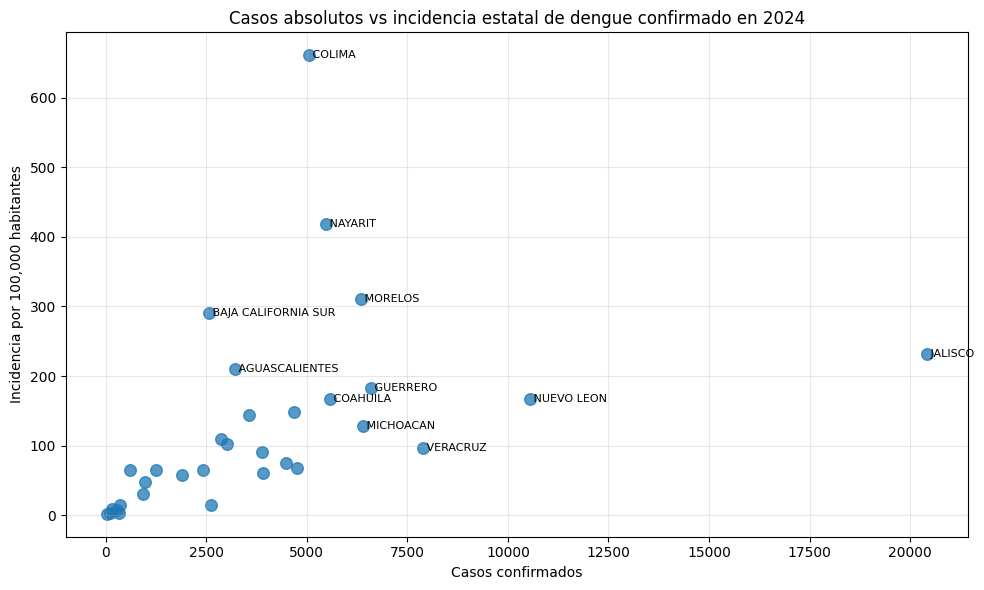

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    comparacion_2024["CASOS_CONFIRMADOS"],
    comparacion_2024["INCIDENCIA_100K"],
    s=70,
    alpha=0.75
)

for _, row in comparacion_2024.iterrows():
    if row["ESTADO"] in estados_etiquetar:
        ax.text(
            row["CASOS_CONFIRMADOS"],
            row["INCIDENCIA_100K"],
            " " + row["ESTADO"],
            fontsize=8,
            va="center"
        )

ax.set_title("Casos absolutos vs incidencia estatal de dengue confirmado en 2024")
ax.set_xlabel("Casos confirmados")
ax.set_ylabel("Incidencia por 100,000 habitantes")

ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig_12_casos_vs_incidencia_estatal_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# Guardar tabla
comparacion_2024.to_csv(
    TABLE_DIR / "tabla_13_casos_vs_incidencia_estatal_2024.csv",
    index=False,
    encoding="utf-8"
)

- Jalisco: muchos casos absolutos y alta incidencia.
- Colima: menos casos absolutos que Jalisco, pero incidencia extremadamente alta.
- Nuevo León: muchos casos absolutos, pero incidencia menor que Colima, Nayarit o Morelos.
- Estado de México: muchos habitantes, por eso su incidencia queda baja aunque tenga más de 2,600 casos.

In [29]:
#  Incidencia anual por región

# Relación estado-región
estado_region = (
    df[["ESTADO", "REGION"]]
    .drop_duplicates()
    .sort_values(["REGION", "ESTADO"])
    .reset_index(drop=True)
)

print("Relación estado-región:")
display(estado_region)

print("\nNúmero de regiones por estado:")
print(
    estado_region
    .groupby("ESTADO")["REGION"]
    .nunique()
    .value_counts()
)


# Casos confirmados por región y año
casos_region_anio = (
    df
    .assign(ANIO=df.index.year)
    .groupby(["ANIO", "REGION"])
    .size()
    .reset_index(name="CASOS_CONFIRMADOS")
)


# Población por región y año
pop_region_anio = (
    pop
    .merge(estado_region, on="ESTADO", how="left")
    .groupby(["ANIO", "REGION"], as_index=False)["POBLACION"]
    .sum()
)

# Cruzar casos y población regional
incidencia_region_anio = pop_region_anio.merge(
    casos_region_anio,
    on=["ANIO", "REGION"],
    how="left"
)

incidencia_region_anio["CASOS_CONFIRMADOS"] = (
    incidencia_region_anio["CASOS_CONFIRMADOS"]
    .fillna(0)
    .astype(int)
)

incidencia_region_anio["INCIDENCIA_100K"] = (
    incidencia_region_anio["CASOS_CONFIRMADOS"]
    / incidencia_region_anio["POBLACION"]
    * 100_000
)

incidencia_region_anio = incidencia_region_anio.sort_values(
    ["ANIO", "REGION"]
).reset_index(drop=True)

print("\nIncidencia anual por región:")
display(incidencia_region_anio.round({"INCIDENCIA_100K": 2}))


# Tabla pivote
incidencia_region_pivot = incidencia_region_anio.pivot(
    index="REGION",
    columns="ANIO",
    values="INCIDENCIA_100K"
)

print("\nIncidencia por región y año:")
display(incidencia_region_pivot.round(2))

Relación estado-región:


,ESTADO,REGION
0,BAJA CALIFORNIA,Region 1
1,BAJA CALIFORNIA SUR,Region 1
2,SINALOA,Region 1
3,SONORA,Region 1
4,CHIHUAHUA,Region 2
5,DURANGO,Region 2
6,ZACATECAS,Region 2
7,COAHUILA,Region 3
8,NUEVO LEON,Region 3
9,SAN LUIS POTOSI,Region 3



Número de regiones por estado:
REGION
1    32
Name: count, dtype: int64

Incidencia anual por región:


,ANIO,REGION,POBLACION,CASOS_CONFIRMADOS,INCIDENCIA_100K
0,2020,Region 1,10735776,768,7.15
1,2020,Region 2,7317820,147,2.01
2,2020,Region 3,15570761,7391,47.47
3,2020,Region 4,15335741,9067,59.12
4,2020,Region 5,21688947,2654,12.24
5,2020,Region 6,7640992,807,10.56
6,2020,Region 7,36647302,1864,5.09
7,2020,Region 8,13271831,1526,11.50
8,2021,Region 1,10842827,1522,14.04
9,2021,Region 2,7377480,6,0.08



Incidencia por región y año:


ANIO,2020,2021,2022,2023,2024,2025,2026
REGION,,,,,,,
Region 1,7.15,14.04,27.49,9.50,73.74,61.72,9.20
Region 2,2.01,0.08,0.89,0.37,22.17,0.26,0.04
Region 3,47.47,7.93,4.11,6.87,131.93,12.47,0.28
Region 4,59.12,3.76,2.54,18.02,235.01,25.77,0.97
Region 5,12.24,8.87,18.15,86.11,103.52,19.35,1.69
Region 6,10.56,1.48,25.15,251.29,69.05,16.19,5.75
Region 7,5.09,2.39,5.58,20.64,37.70,2.24,0.04
Region 8,11.50,0.37,0.08,14.11,85.46,14.73,0.08


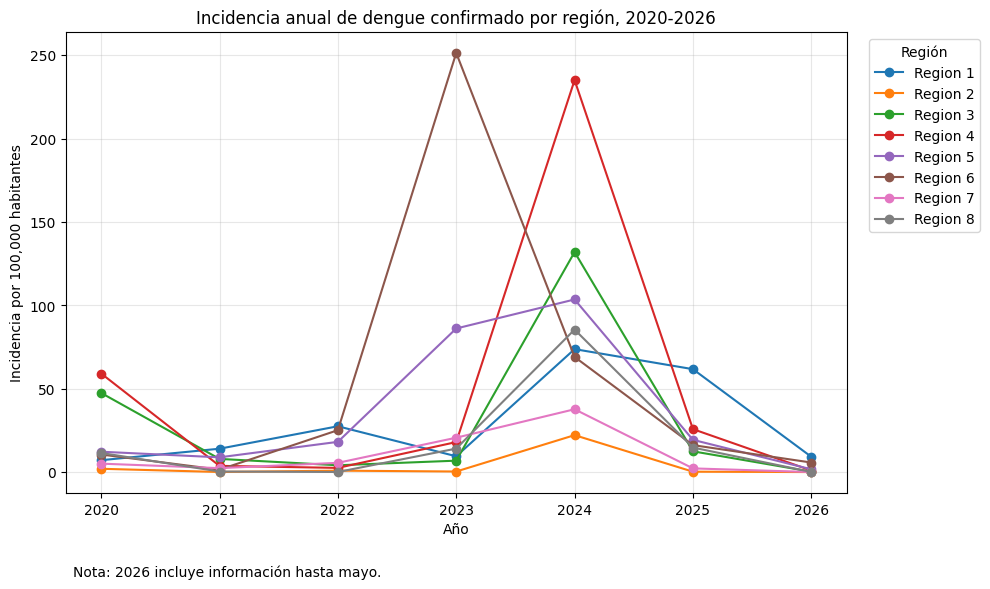

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

for region in incidencia_region_pivot.index:
    ax.plot(
        incidencia_region_pivot.columns,
        incidencia_region_pivot.loc[region],
        marker="o",
        label=region
    )

ax.set_title("Incidencia anual de dengue confirmado por región, 2020-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Incidencia por 100,000 habitantes")
ax.set_xticks(incidencia_region_pivot.columns)
ax.grid(True, alpha=0.3)
ax.legend(title="Región", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.text(
    0.01,
    -0.18,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_13_incidencia_anual_por_region_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


incidencia_region_anio.to_csv(
    TABLE_DIR / "tabla_14_incidencia_anual_por_region.csv",
    index=False,
    encoding="utf-8"
)

incidencia_region_pivot.to_csv(
    TABLE_DIR / "tabla_15_incidencia_region_anio_pivot.csv",
    encoding="utf-8"
)

2023:
- Region 6 tuvo el pico regional más alto: 251.3 por 100,000.
- Esto coincide con la fuerte carga en Yucatán, Quintana Roo, Tabasco y Campeche.

2024:
- Region 4 fue la más alta: 235.0 por 100,000.
- Le siguieron Region 3, Region 5 y Region 8.

2025:
- Region 1 mantiene una incidencia relativamente alta: 61.7 por 100,000.

Incidencia regional anual por 100,000 habitantes:


ANIO,2020,2021,2022,2023,2024,2025,2026
REGION,,,,,,,
Region 1,7.15,14.04,27.49,9.50,73.74,61.72,9.20
Region 2,2.01,0.08,0.89,0.37,22.17,0.26,0.04
Region 3,47.47,7.93,4.11,6.87,131.93,12.47,0.28
Region 4,59.12,3.76,2.54,18.02,235.01,25.77,0.97
Region 5,12.24,8.87,18.15,86.11,103.52,19.35,1.69
Region 6,10.56,1.48,25.15,251.29,69.05,16.19,5.75
Region 7,5.09,2.39,5.58,20.64,37.70,2.24,0.04
Region 8,11.50,0.37,0.08,14.11,85.46,14.73,0.08


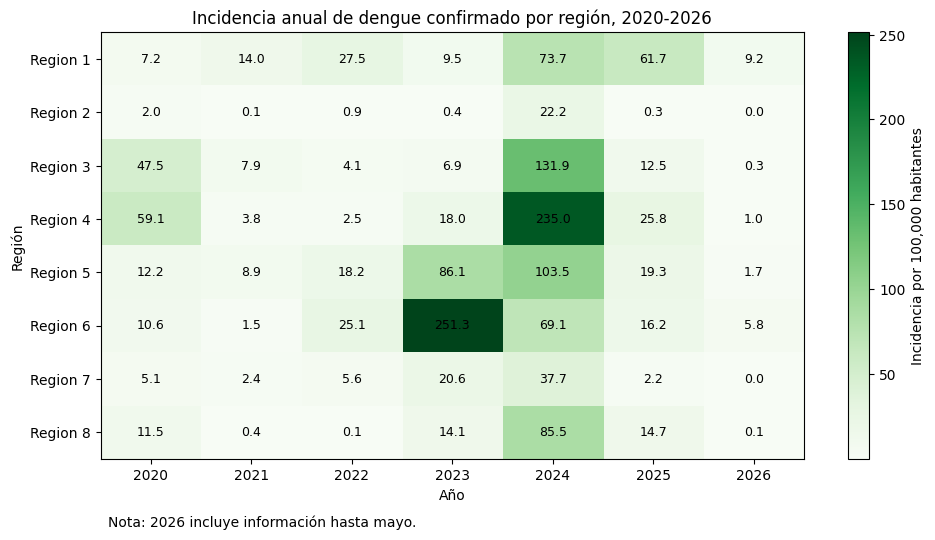

In [31]:
# Mapa de calor de incidencia regional anual

print("Incidencia regional anual por 100,000 habitantes:")
display(incidencia_region_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 5.5))

im = ax.imshow(
    incidencia_region_pivot.values,
    aspect="auto", cmap='Greens'
)

ax.set_title("Incidencia anual de dengue confirmado por región, 2020-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Región")

ax.set_xticks(range(len(incidencia_region_pivot.columns)))
ax.set_xticklabels(incidencia_region_pivot.columns)

ax.set_yticks(range(len(incidencia_region_pivot.index)))
ax.set_yticklabels(incidencia_region_pivot.index)

# Etiquetas dentro de cada celda
for i in range(incidencia_region_pivot.shape[0]):
    for j in range(incidencia_region_pivot.shape[1]):
        valor = incidencia_region_pivot.iloc[i, j]
        ax.text(
            j,
            i,
            f"{valor:.1f}",
            ha="center",
            va="center",
            fontsize=9
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Incidencia por 100,000 habitantes")

ax.text(
    0.01,
    -0.16,
    "Nota: 2026 incluye información hasta mayo.",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()

fig_path = FIG_DIR / "fig_14_heatmap_incidencia_region_anio_dengue_2020_2026.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


incidencia_region_pivot.to_csv(
    TABLE_DIR / "tabla_16_heatmap_incidencia_region_anio.csv",
    encoding="utf-8"
)


2023:
- Region 6 fue la más alta, con 251.3 casos por 100,000 habitantes.
- Esto corresponde al bloque Campeche, Quintana Roo, Tabasco y Yucatán.

2024:
- Region 4 fue la más alta, con 235.0 por 100,000.
- Le siguieron Region 3, Region 5 y Region 8.

2025:
- Region 1 todavía mantiene una incidencia relativamente alta, con 61.7 por 100,000.

In [32]:
# Resumen de archivos generados

print("Tablas de incidencia guardadas en:")
print(TABLE_DIR.resolve())

print("\nArchivos CSV generados:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print("-", path.name)

print("\nFiguras de incidencia guardadas en:")
print(FIG_DIR.resolve())

print("\nFiguras PNG generadas:")
for path in sorted(FIG_DIR.glob("*.png")):
    print("-", path.name)

Tablas de incidencia guardadas en:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/tablas_incidencia

Archivos CSV generados:
- tabla_01_incidencia_estatal_anual.csv
- tabla_02_incidencia_nacional_anual.csv
- tabla_03_heatmap_incidencia_estatal_anual.csv
- tabla_04_top15_estados_incidencia_2024.csv
- tabla_05_incidencia_nacional_mensual.csv
- tabla_06_estacionalidad_mensual_incidencia_nacional.csv
- tabla_07_incidencia_mensual_top10_estados_2024.csv
- tabla_08_heatmap_incidencia_mensual_top10_estados_2024.csv
- tabla_09_mes_pico_incidencia_estatal_2024.csv
- tabla_10_numero_estados_mes_pico_2024.csv
- tabla_11_resumen_incidencia_estatal.csv
- tabla_12_resumen_incidencia_estatal_2020_2025.csv
- tabla_13_casos_vs_incidencia_estatal_2024.csv
- tabla_14_incidencia_anual_por_region.csv
- tabla_15_incidencia_region_anio_pivot.csv
- tabla_16_heatmap_incidencia_region_anio.csv

Figuras de incidencia guardadas en:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historic

## Resumen del análisis de incidencia

En este notebook se calculó la incidencia de casos confirmados de dengue en México durante el periodo 2020--2026, utilizando como denominador la población estatal anual. La incidencia se expresó como casos confirmados por cada 100,000 habitantes.

A nivel nacional, el año con mayor incidencia fue 2024, con 93.1 casos por 100,000 habitantes. En segundo lugar se ubicó 2023, con 40.7 casos por 100,000 habitantes. El año 2026 debe interpretarse con cautela, ya que sólo contiene información hasta mayo.

El análisis estatal mostró diferencias importantes entre carga absoluta e incidencia relativa. En 2024, Jalisco concentró el mayor número absoluto de casos confirmados; sin embargo, Colima presentó la mayor incidencia estatal, con 661.5 casos por 100,000 habitantes. También destacaron Nayarit, Morelos, Baja California Sur, Jalisco y Aguascalientes.

El análisis mensual mostró una marcada estacionalidad. A nivel nacional, los picos más altos se concentraron entre agosto y octubre, especialmente durante 2024. En ese año, 19 de los 32 estados alcanzaron su mes pico entre septiembre y octubre. Algunos estados, como Guerrero, Tabasco, Campeche, Quintana Roo y Yucatán, tuvieron su máximo en enero, lo cual puede interpretarse como continuidad de la onda epidémica del segundo semestre de 2023.

A nivel regional, la mayor incidencia en 2023 se observó en la Region 6, conformada por Campeche, Quintana Roo, Tabasco y Yucatán. En 2024, la mayor incidencia regional correspondió a la Region 4, integrada por Colima, Jalisco, Michoacán y Nayarit.

En conjunto, los resultados muestran que el brote de 2024 no sólo fue el de mayor carga nacional, sino que también presentó una fuerte heterogeneidad espacial, con estados pequeños como Colima y Nayarit mostrando incidencias muy superiores al promedio nacional.
